In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import pickle
import re

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
import kagglehub
path = kagglehub.dataset_download("ashishkumarak/amazon-shopping-reviews-daily-updated")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-shopping-reviews-daily-updated' dataset.
Path to dataset files: /kaggle/input/amazon-shopping-reviews-daily-updated


In [ ]:
import pandas as pd
import os
files = os.listdir(path)
print(files)
df = pd.read_csv(os.path.join(path, files[0]))
print(f"Dataset shape : {df.shape}")

['amazon_reviews.csv']
Dataset shape : (83800, 8)


In [ ]:
df.head()

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,41b9c898-c11f-41f7-99bf-ceb9d6a2504b,Tori,Worst company,1,0,30.12.4.100,2026-01-27 10:25:48,30.12.4.100
1,c72f9857-6811-4131-b822-941e8ded982b,Naomi Gehan,why no longer available on tablets? extremely ...,1,0,32.2.0.100,2026-01-27 10:19:35,32.2.0.100
2,68836ec5-cb3c-4f97-920d-f9bce9422e7c,Tony Murray,very 😭 sad Amazon shopping is no longer availa...,1,0,NaN,2026-01-27 09:58:37,NaN
3,8039cf9c-3235-4695-a8f6-e119008cbf5d,Valorie,good for the most part. my main issue is that ...,3,0,32.2.0.100,2026-01-27 09:26:51,32.2.0.100
4,5c452062-7139-404a-a488-976ad3dbc42f,Suree Doty,love prime,4,0,32.2.0.100,2026-01-27 09:21:58,32.2.0.100


In [ ]:
df.isnull().sum

<bound method DataFrame.sum of        reviewId  userName  content  score  thumbsUpCount  \
0         False     False    False  False          False   
1         False     False    False  False          False   
2         False     False    False  False          False   
3         False     False    False  False          False   
4         False     False    False  False          False   
...         ...       ...      ...    ...            ...   
83795     False     False    False  False          False   
83796     False     False    False  False          False   
83797     False     False    False  False          False   
83798     False     False    False  False          False   
83799     False     False    False  False          False   

       reviewCreatedVersion     at  appVersion  
0                     False  False       False  
1                     False  False       False  
2                      True  False        True  
3                     False  False       False  
4                     False  False       False  
...                     ...    ...         ...  
83795                 False  False       False  
83796                 False  False       False  
83797                 False  False       False  
83798                 False  False       False  
83799                 False  False       False  

[83800 rows x 8 columns]>

reviewCreatedVersion and appVersion containing a large number of null values

In [ ]:
for i, col in enumerate(df.columns):
    print(i, repr(col))

0 'reviewId'
1 'userName'
2 'content'
3 'score'
4 'thumbsUpCount'
5 'reviewCreatedVersion'
6 'at'
7 'appVersion'


In [ ]:
df.isna().sum()

,0
reviewId,0
userName,6
content,6
score,0
thumbsUpCount,0
reviewCreatedVersion,9580
at,0
appVersion,9580


In [ ]:
df[df['content'].isna()]
df[df['userName'].isna()]

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
8622,227f2f27-4706-466b-b355-bb255c996b1d,NaN,I give any app 1 star that hassles me with a p...,1,0,30.11.0.100,2025-06-19 05:12:03,30.11.0.100
40307,995f40d6-7261-410b-9142-90ca70196cb5,NaN,They wanted my license plate number and what s...,1,0,26.23.0.100,2023-12-17 21:40:51,26.23.0.100
48910,b45b6f8e-6723-4524-bb17-650a42ec61d6,NaN,It seemed to work okay until about a week ago....,1,0,NaN,2021-02-23 18:16:04,NaN
58655,8e981d0c-d33e-46b9-9213-d469a46ada5a,NaN,Search doesn't work. lists things you don't wa...,1,0,22.22.0.100,2024-01-18 19:12:15,22.22.0.100
59080,4ede14fe-f88d-4c2f-806f-45ecf15b9938,NaN,Nightmare service. Try calling support. You'll...,1,0,26.19.2.100,2023-10-02 13:24:23,26.19.2.100
61179,865858aa-df7b-4e66-ac83-535ca266afd4,NaN,Mostly good app but prime day was a lame and p...,4,4,20.20.0.100,2020-10-15 13:06:39,20.20.0.100


In [ ]:
df.dropna(inplace=True)

In [ ]:
print(f"Dataset shape after dropping null values : {df.shape}")

Dataset shape after dropping null values : (74212, 8)


In [ ]:
df['length'] = df['content'].apply(len)

In [ ]:
df.head()

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,length
0,41b9c898-c11f-41f7-99bf-ceb9d6a2504b,Tori,Worst company,1,0,30.12.4.100,2026-01-27 10:25:48,30.12.4.100,13
1,c72f9857-6811-4131-b822-941e8ded982b,Naomi Gehan,why no longer available on tablets? extremely ...,1,0,32.2.0.100,2026-01-27 10:19:35,32.2.0.100,59
3,8039cf9c-3235-4695-a8f6-e119008cbf5d,Valorie,good for the most part. my main issue is that ...,3,0,32.2.0.100,2026-01-27 09:26:51,32.2.0.100,186
4,5c452062-7139-404a-a488-976ad3dbc42f,Suree Doty,love prime,4,0,32.2.0.100,2026-01-27 09:21:58,32.2.0.100,10
6,a231e2e4-7148-48b6-9040-fc9c5004f641,Probably Sleeping,please put dark mode. thank you.,1,0,32.2.0.100,2026-01-27 09:00:25,32.2.0.100,32


In [ ]:
df['content'] = df['content'].astype(str)
df['length'] = df['content'].apply(lambda x: len(str(x)))
print(f"content column value : {df['content'].iloc[1]}")
print(f"length of review : {len(df['content'].iloc[1])} ")
print(f"length column value : {df['length'].iloc[1]}")

content column value : why no longer available on tablets? extremely inconvenient.
length of review : 59 
length column value : 59


Data Types

In [ ]:
df.dtypes

,0
reviewId,object
userName,object
content,object
score,int64
thumbsUpCount,int64
reviewCreatedVersion,object
at,object
appVersion,object
length,int64


Analyzing 'score' column

In [ ]:
len(df)

74212

In [ ]:
print(f"score value count: \n{df['score'].value_counts()}")

score value count: 
score
1    33111
5    21771
2     8091
3     6301
4     4938
Name: count, dtype: int64


In [ ]:
print(f"Unique values in score column : {df['score'].unique()}")

Unique values in score column : [1 3 4 5 2]


Let's plot the above values in a Bar Graph (for score)

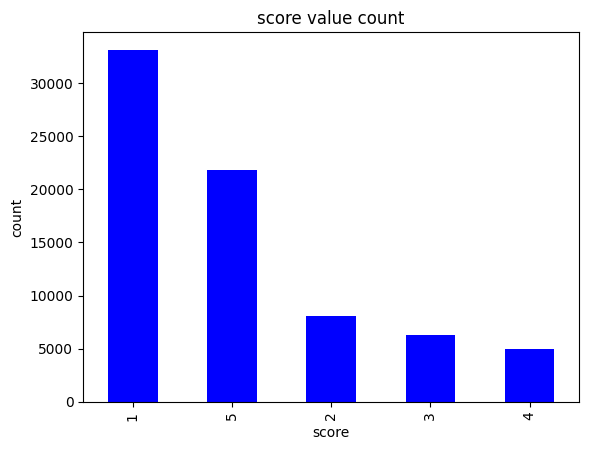

In [ ]:
df['score'].value_counts().plot.bar(color='blue')
plt.title("score value count")
plt.xlabel("score")
plt.ylabel("count")
plt.show()

Pie Chart

([<matplotlib.patches.Wedge at 0x7a69eb152720>,
 [Text(0.18514533475261818, 1.0843067854714095, '1'),
  Text(-0.9180621661382274, -0.6059388245570554, '3'),
  Text(0.3005312409204156, -1.0581497877100554, '4'),
  Text(0.8519891930160964, -0.6957833103659363, '5'),
  Text(1.0760538640297557, -0.22827194682359067, '2')],
 [Text(0.10098836441051899, 0.5914400648025869, '45%'),
  Text(-0.5007611815299422, -0.33051208612203015, '29%'),
  Text(0.16392613141113577, -0.577172611478212, '11%'),
  Text(0.46472137800877983, -0.3795181692905107, '8%'),
  Text(0.5869384712889576, -0.1245119709946858, '7%')])

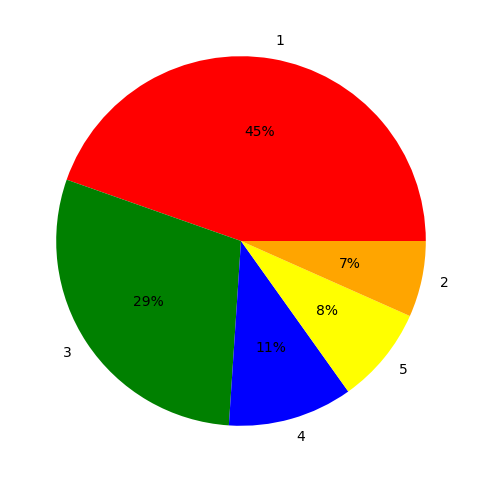

In [ ]:
fig = plt.figure(figsize=(6,6))
colors = ('red','green','blue','yellow','orange')
plt.pie(df['score'].value_counts(),
labels=df['score'].unique(),
colors=colors,
autopct='%.0f%%')

Since our feedback in the table is named as content.
Let's analyze count

In [ ]:
print(f"content value count: \n{df['content'].value_counts()}")

content value count: 
content
good                                                                                                                                                                                                                                                    247
Good                                                                                                                                                                                                                                                    223
Great                                                                                                                                                                                                                                                   165
great                                                                                                                                                                                                                 

Bar Graph (for content/feedback)

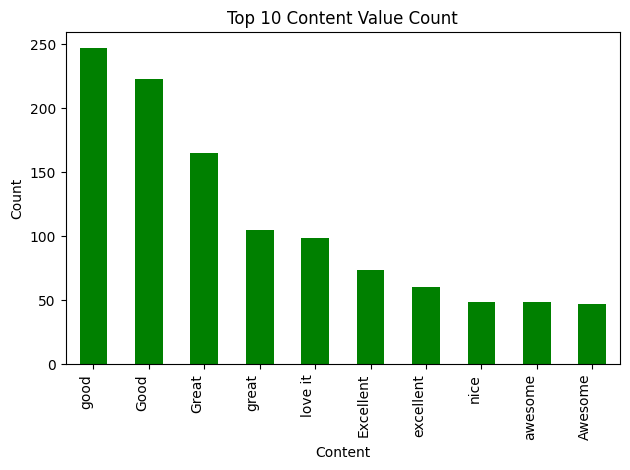

In [ ]:
import matplotlib as mpl
top_content_counts = df['content'].value_counts().head(10)
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.default'] = 'regular'
top_content_counts.plot.bar(color='green')
plt.title("Top 10 Content Value Count")
plt.xlabel("Content")
plt.ylabel("Count")
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

Pie Chart

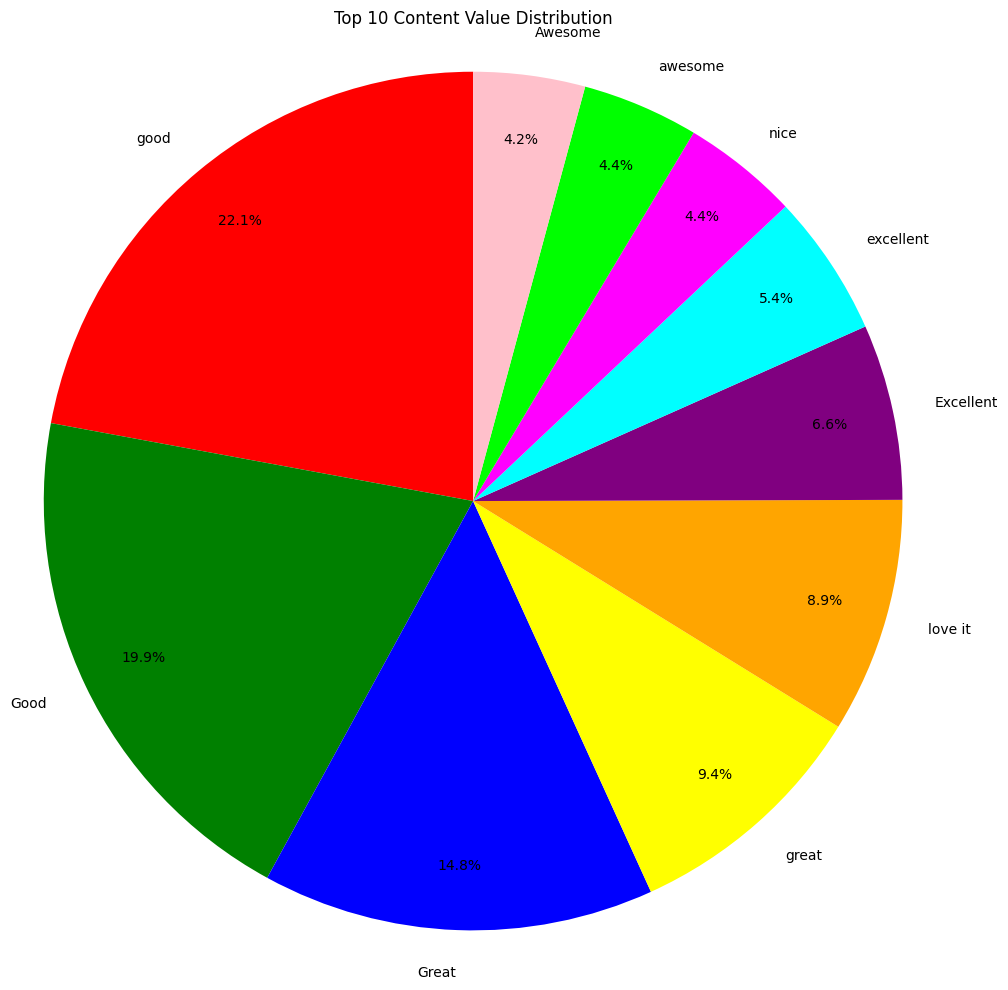

In [ ]:
import matplotlib as mpl
top_content_counts = df['content'].value_counts().head(10)
pie_labels = top_content_counts.index.tolist()
pie_values = top_content_counts.values
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.default'] = 'regular'
fig = plt.figure(figsize=(10, 10))
colors = ['red', 'green', 'blue', 'yellow', 'orange', 'purple', 'cyan', 'magenta', 'lime', 'pink']
plt.pie(pie_values,
        labels=pie_labels,
        colors=colors[:len(pie_values)],
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.85
       )
plt.title("Top 10 Content Value Distribution")
plt.axis('equal')
plt.tight_layout()
plt.show()

Let's see the 'score' values for different values of 'content'

In [ ]:
print("Examining score distribution for the top 5 most frequent content entries:")
top_5_content = df['content'].value_counts().head(5)
for content_text, count in top_5_content.items():
    print(f"--- Content: '{content_text}' (appears {count} times) ---")
    score_distribution = df[df['content'] == content_text]['score'].value_counts().sort_index()
    if not score_distribution.empty:
        print(score_distribution)
    else:
        print("No scores found for this content.")
    print()

Examining score distribution for the top 5 most frequent content entries:
--- Content: 'good' (appears 247 times) ---
score
1      3
2      5
3     12
4     26
5    201
Name: count, dtype: int64

--- Content: 'Good' (appears 223 times) ---
score
1      3
2      4
3     11
4     30
5    175
Name: count, dtype: int64

--- Content: 'Great' (appears 165 times) ---
score
1      1
3      3
4     16
5    145
Name: count, dtype: int64

--- Content: 'great' (appears 105 times) ---
score
3      2
4      3
5    100
Name: count, dtype: int64

--- Content: 'love it' (appears 99 times) ---
score
4     8
5    91
Name: count, dtype: int64



Calculating mean of score and content

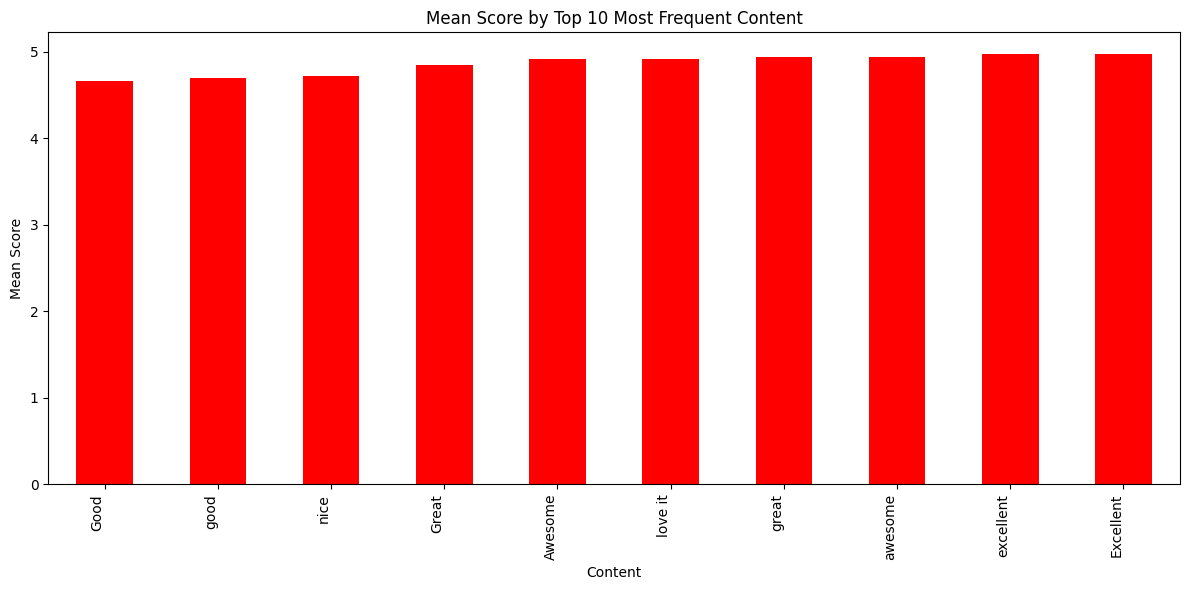

In [ ]:
import matplotlib as mpl
top_10_content = df['content'].value_counts().head(10).index
df_top_content = df[df['content'].isin(top_10_content)]
mean_scores_top_content = df_top_content.groupby('content')['score'].mean().sort_values()
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.default'] = 'regular'
mean_scores_top_content.plot.bar(color = 'red', figsize = (12, 6))
plt.title('Mean Score by Top 10 Most Frequent Content')
plt.xlabel('Content')
plt.ylabel('Mean Score')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

Analyzing 'reviewId'

In [ ]:
df['length'].describe()

,length
count,74212.000000
mean,185.874373
std,144.336832
min,1.000000
25%,78.000000
50%,145.000000
75%,270.000000
max,1594.000000


Length analysis for full dataset

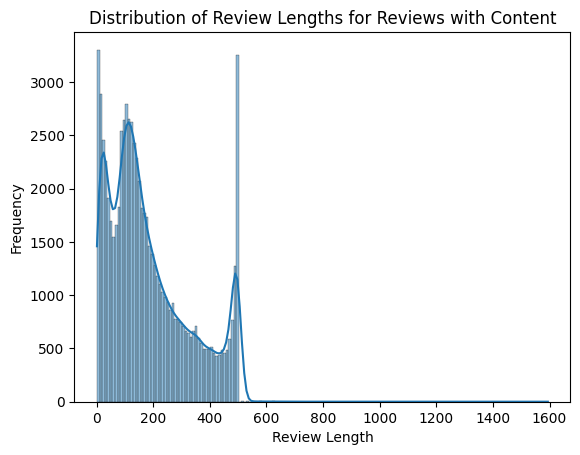

In [ ]:
sns.histplot(df['length'], kde=True)
plt.title('Distribution of Review Lengths for Reviews with Content')
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.show()

Length wise mean rating

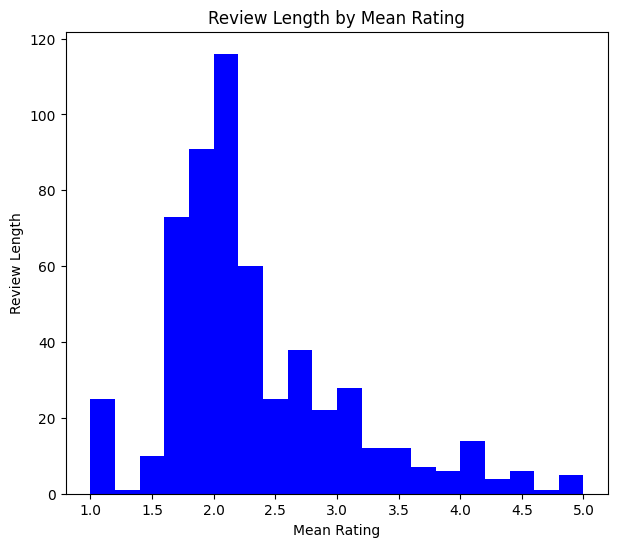

In [ ]:
df.groupby('length')['score'].mean().plot.hist(color='blue',figsize = (7,6), bins=20)
plt.title('Review Length by Mean Rating')
plt.xlabel('Mean Rating')
plt.ylabel('Review Length')
plt.show()

In [ ]:
cv = CountVectorizer(stop_words='english')
words = cv.fit_transform(df['content'])

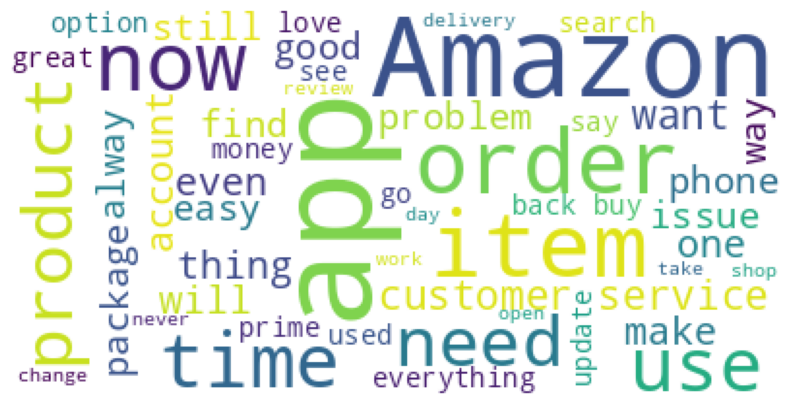

In [ ]:
content = " ".join([content for content in df['content']])
wc = WordCloud(background_color='white', max_words=50)
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(content))
plt.axis('off')
plt.show()

**Preprocessing and Modeling**

To build the corpus from the 'content' we perfrom the following-

1. Replace any non alphabet characters with a space
2. Convert to lower case and split into words
3. Iterate over the individual words and if it is not a stopword then add the stemmed form of the word to the corpus

In [ ]:
corpus = []
stemmer = PorterStemmer()
for i in range(len(df)):
    text = re.sub('[^a-zA-Z]', ' ', df['content'].iloc[i])
    text = text.lower().split()
    text = [stemmer.stem(word) for word in text if word not in STOPWORDS]
    text = ' '.join(text)
    corpus.append(text)

Using Count Vectorizer to create bag of words

In [ ]:
cv = CountVectorizer(max_features=5000)
X = cv.fit_transform(corpus).toarray()
y = df['score']

In [ ]:
pickle.dump(cv, open('cv.pkl', 'wb'))

Checking the shape of X and y

In [ ]:
print(f"Shape of X : {X.shape}")
print(f"Shape of y : {y.shape}")

Shape of X : (74212, 5000)
Shape of y : (74212,)


Splitting data into train and test set with 30% data with testing.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of y_train : {y_train.shape}")
print(f"Shape of X_test : {X_test.shape}")
print(f"Shape of y_test : {y_test.shape}")

Shape of X_train : (51948, 5000)
Shape of y_train : (51948,)
Shape of X_test : (22264, 5000)
Shape of y_test : (22264,)


In [ ]:
print(f"X train max value : {X_train.max()}")
print(f"y train min value : {X_test.min()}")

X train max value : 12
y train min value : 0


We'll scale X_train and X_test so that all values are between 0 and 1

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))

Random Forest

In [ ]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
print("Training Accuracy :", model_rf.score(X_train, y_train))
print("Testing Accuracy :", model_rf.score(X_test, y_test))

Training Accuracy : 0.9832139832139832
Testing Accuracy : 0.6801113905856989


In [ ]:
y_preds = model_rf.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test, y_preds)
print(cm)

[[9311   46   27   26  497]
 [2232   19    9    7  172]
 [1553   14   24   21  293]
 [ 667    7   13   29  772]
 [ 690    9   16   51 5759]]


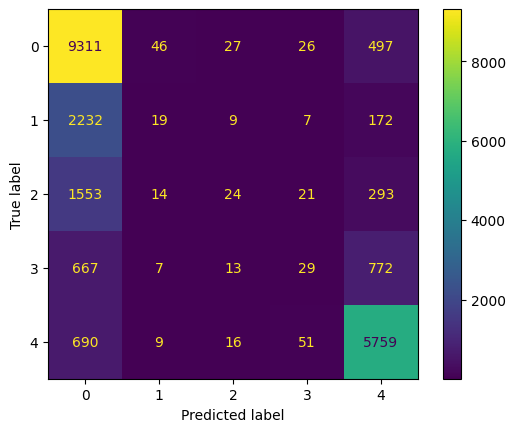

In [ ]:
cm = confusion_matrix(y_test, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Decision Tree Classifier

In [ ]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Accuracy of the model on training and testing data
print("Training Accuracy :", model_dt.score(X_train, y_train))
print("Testing Accuracy :", model_dt.score(X_test, y_test))

Training Accuracy : 0.9832524832524833
Testing Accuracy : 0.5627919511318721


In [ ]:
y_preds = model_dt.predict(X_test)

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_preds)
print(cm)

[[6760 1086  723  400  938]
 [1459  324  246  149  261]
 [ 958  271  215  155  306]
 [ 419  102  137  167  663]
 [ 759  142  149  411 5064]]


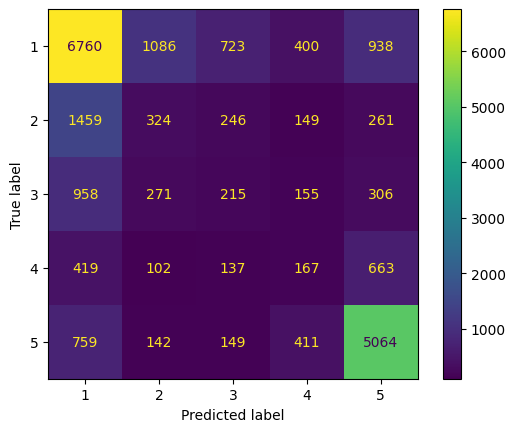

In [ ]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_dt.classes_)
cm_display.plot()
plt.show()

In [ ]:
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)